# Credit Card Fraud Detection using Machine Learning

## Objective

The objective of this project is to develop a machine learning model that identifies fraudulent credit card transactions based on transaction features. The model aims to distinguish between genuine and fraudulent transactions while effectively handling an imbalanced dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Loading the Dataset

In [5]:
import os

print(os.listdir("Dataset"))    

['creditcard.csv', 'creditcard.csv.zip']


In [6]:
import os

print(os.path.isfile("Dataset/creditcard.csv"))
print(os.path.isdir("Dataset/creditcard.csv"))

False
True


In [7]:
import os

print(os.path.isfile("Dataset/creditcard.csv"))
print(os.path.isdir("Dataset/creditcard.csv"))

False
True


In [8]:
import os

print(os.listdir("Dataset/creditcard.csv"))

['creditcard.csv']


In [9]:
df = pd.read_csv("Dataset/creditcard.csv/creditcard.csv")

print("Dataset Loaded Successfully!\n")

df.head()

Dataset Loaded Successfully!



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

print(df.isnull().sum())

Shape of Dataset: (284807, 31)

Column Names:

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float6

## Data Cleaning

The dataset contains no missing values. Therefore, no additional data cleaning was required before model training.

## Class Distribution

The dataset is highly imbalanced, with a much larger number of legitimate transactions than fraudulent transactions. Understanding this imbalance is essential before training the machine learning model.

In [11]:
print(df["Class"].value_counts())

print("\nPercentage Distribution:\n")

print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


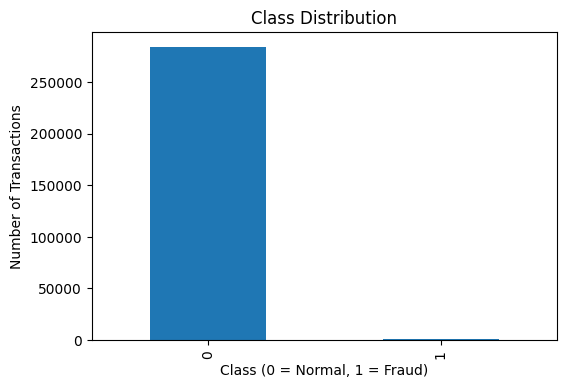

In [12]:
plt.figure(figsize=(6,4))

df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.savefig("screenshots/class_distribution.png")

plt.show()

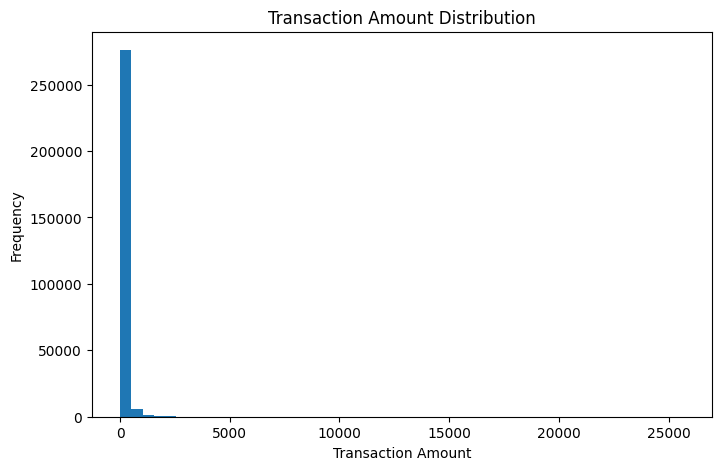

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.savefig("screenshots/amount_distribution.png")

plt.show()

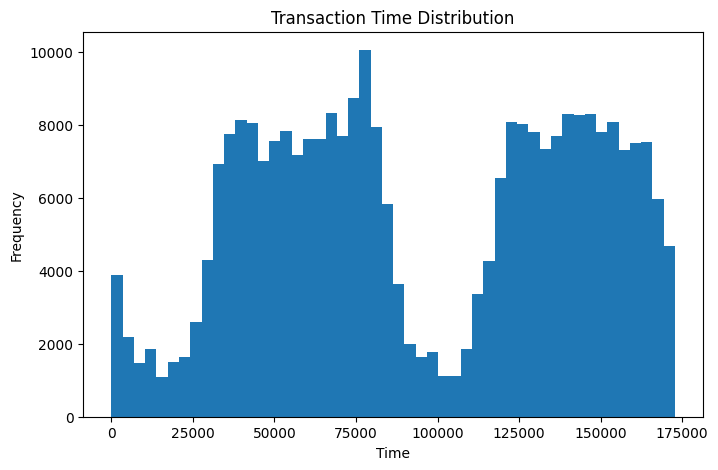

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.savefig("screenshots/time_distribution.png")

plt.show()

C:\Users\my pc\AppData\Local\Temp\ipykernel_28004\3480784977.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


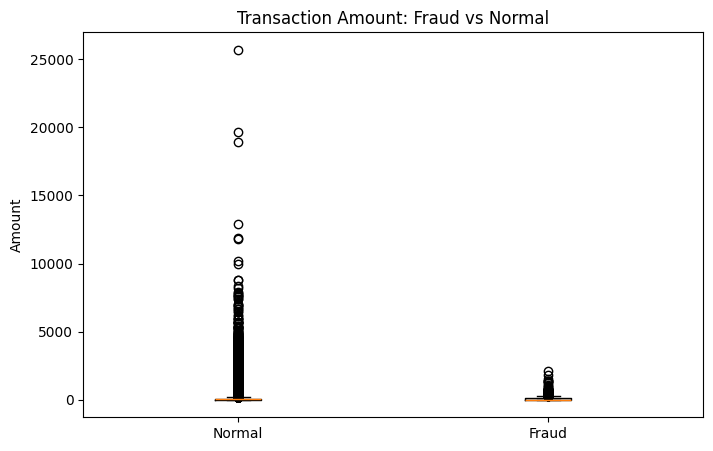

In [15]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df[df["Class"] == 0]["Amount"],
        df[df["Class"] == 1]["Amount"]
    ],
    labels=["Normal", "Fraud"]
)

plt.title("Transaction Amount: Fraud vs Normal")
plt.ylabel("Amount")

plt.savefig("screenshots/fraud_vs_normal_amount.png")

plt.show()

In [16]:
import seaborn as sns

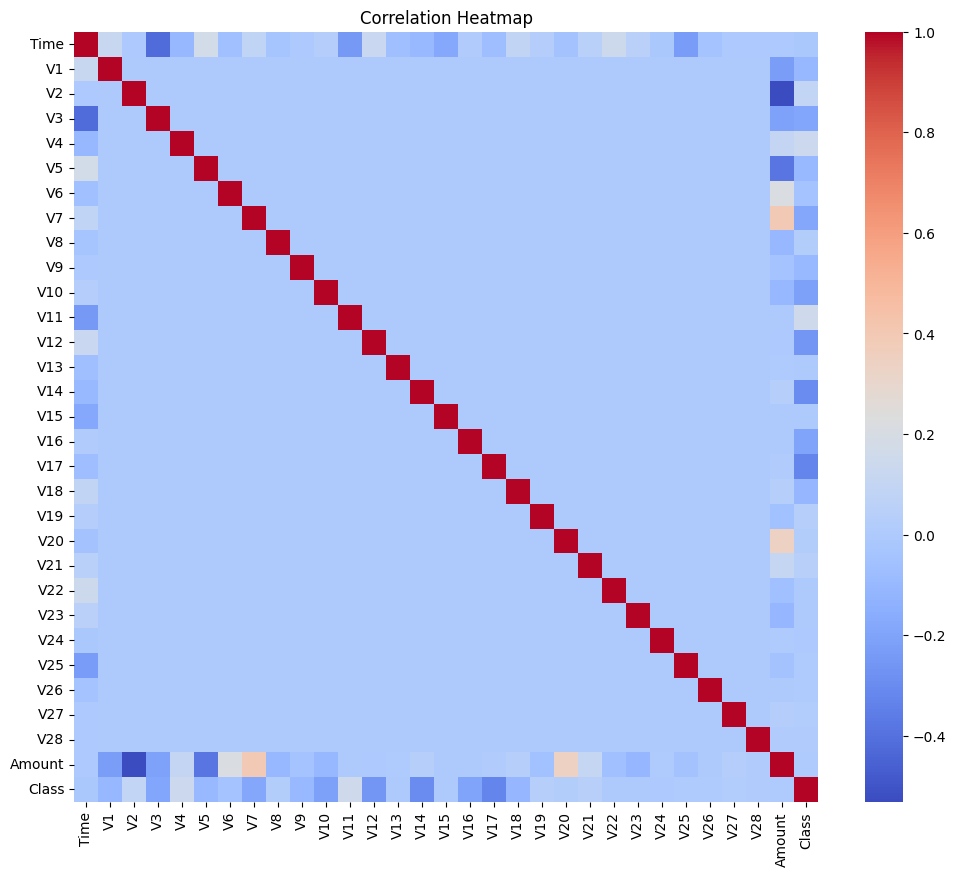

In [17]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("screenshots/correlation_heatmap.png")

plt.show()

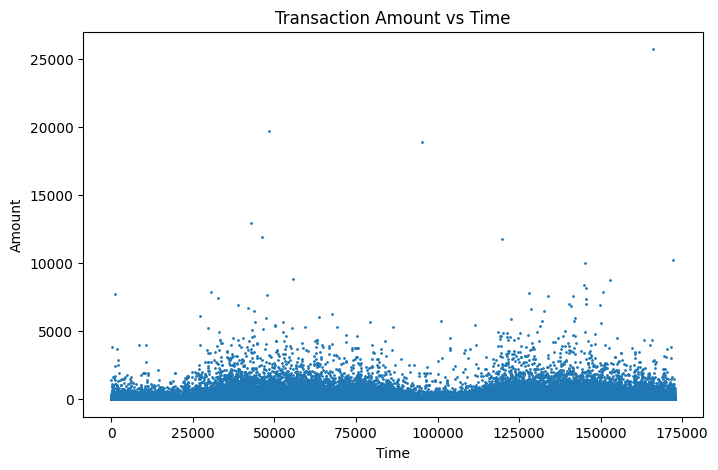

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df["Time"], df["Amount"], s=1)

plt.title("Transaction Amount vs Time")
plt.xlabel("Time")
plt.ylabel("Amount")

plt.savefig("screenshots/amount_vs_time.png")

plt.show()

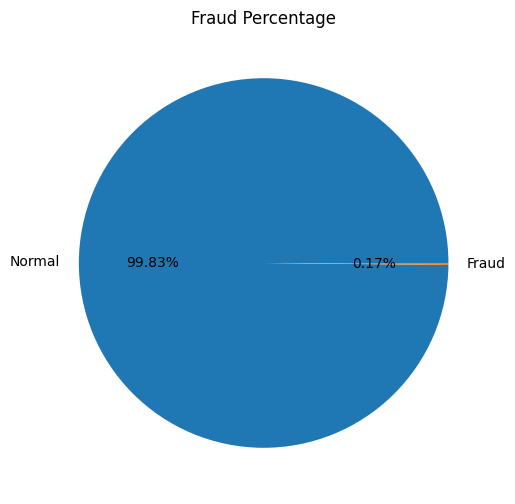

In [19]:
fraud_counts = df["Class"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=["Normal","Fraud"],
    autopct="%1.2f%%"
)

plt.title("Fraud Percentage")

plt.savefig("screenshots/fraud_percentage.png")

plt.show()

## Feature Engineering

The dataset already contains numerical features. Therefore, no encoding is required. The **Class** column is used as the target variable, while all remaining columns are used as input features.

In [20]:
# Features and Target

X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (284807, 30)
Target Shape: (284807,)


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to train the model, while the testing data is used to evaluate its performance.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (227845, 30)
Testing Data Shape: (56962, 30)


## Model Training

A Random Forest Classifier is trained to distinguish between legitimate and fraudulent transactions based on the transaction features.

In [23]:
model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Model Evaluation

The trained Random Forest model is evaluated using Accuracy Score, Confusion Matrix, Classification Report, Precision, Recall, and F1-Score to assess its fraud detection performance.

In [25]:
# Predictions

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9995962220427653


In [26]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[56859     5]
 [   18    80]]


In [27]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



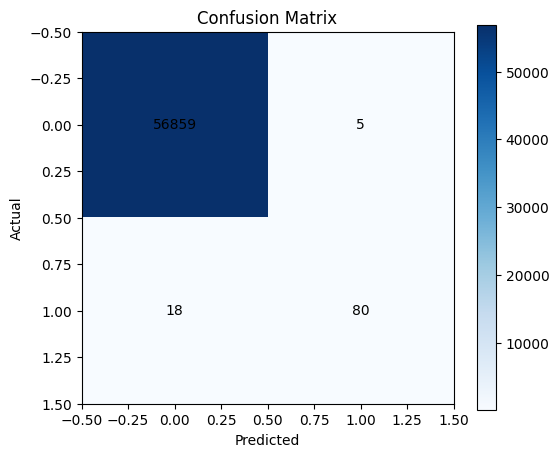

In [28]:
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.savefig("screenshots/confusion_matrix.png")

plt.show()

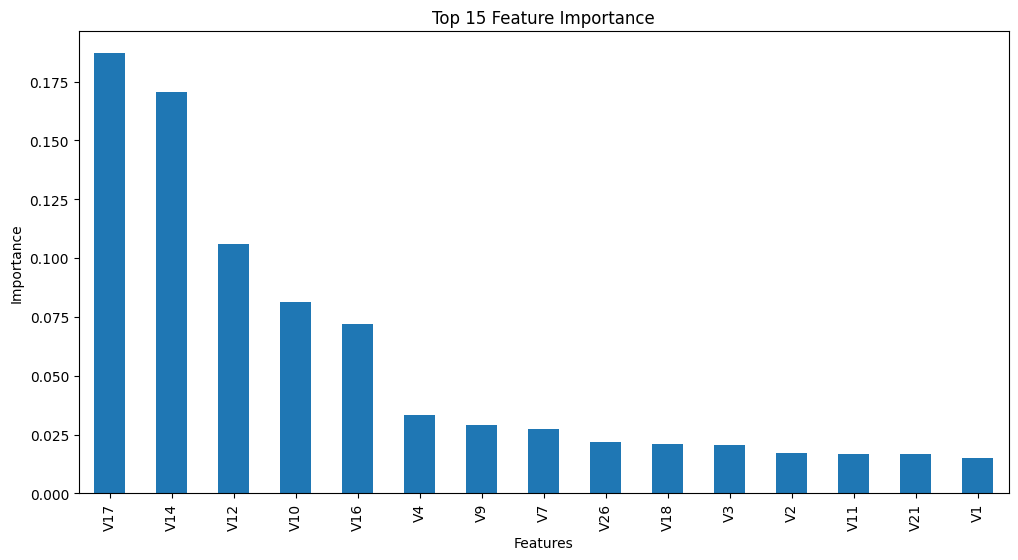

In [29]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12,6))

feature_importance.head(15).plot(kind="bar")

plt.title("Top 15 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.savefig("screenshots/feature_importance.png")

plt.show()

In [30]:
from sklearn.metrics import roc_curve, auc

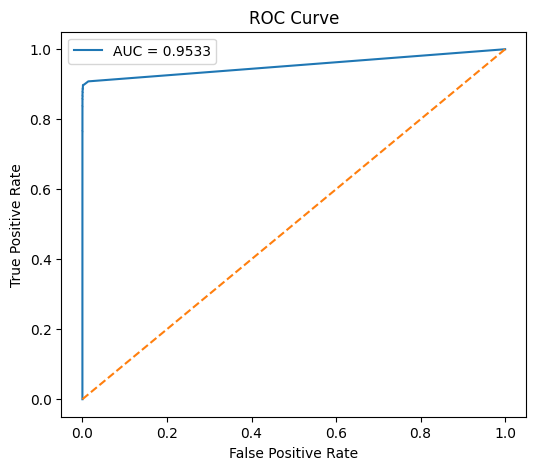

In [31]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("screenshots/roc_curve.png")

plt.show()

In [32]:
from sklearn.metrics import precision_recall_curve

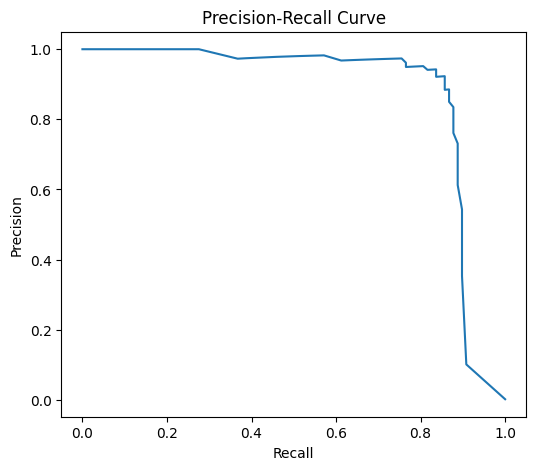

In [33]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.savefig("screenshots/precision_recall_curve.png")

plt.show()

# Conclusion

A Random Forest Classifier was successfully developed to detect fraudulent credit card transactions.

### Workflow Completed

- Data Loading
- Dataset Exploration
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Train-Test Split
- Model Training
- Model Evaluation
- Results Visualization

### Key Highlights

- Successfully handled a highly imbalanced dataset.
- Achieved excellent classification performance using Random Forest.
- Evaluated the model using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC Curve.
- Identified the most influential transaction features through Feature Importance analysis.

The model demonstrated strong performance in distinguishing fraudulent transactions from legitimate ones, making it suitable as a baseline fraud detection system.